In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cosmolopy.distance as cd
import cosmolopy.constants as cc
import afterglowpy as grb
import pandas as pd
from scipy.interpolate import interp1d
from scipy import interpolate
from scipy.integrate import quad
from astropy.time import Time

In [2]:
from astropy.cosmology import Planck18 as cosmo
cosmo.luminosity_distance(0.0085).value * 3.08e24

1.1675363360129222e+26

## Compute SN light curve 

The flux of the supernova (in mJy) is saved in the `sn_flux.txt` file for each of the filter U, B, V, R and I.

In [3]:
file = '/home/masson/orphans/data/sn_flux.txt'
df_sn = pd.read_table(file, sep=' ', header=2, names=['t[days]', 'U', 'B', 'V', 'R', 'I'])
df_sn

,t[days],U,B,V,R,I
0,8.510,3.736,7.248,8.771,7.187,5.40
1,10.430,4.925,8.020,10.440,8.561,6.37
2,12.430,5.253,8.794,11.670,9.562,7.05
3,13.430,5.302,9.041,11.990,9.920,7.38
4,15.360,5.501,9.124,12.790,10.580,7.88
5,19.500,3.912,7.520,11.770,10.670,7.95
6,21.490,3.165,6.549,10.740,10.290,7.80
7,22.450,2.887,5.918,10.160,10.010,7.59
8,23.410,2.468,5.202,9.618,9.650,7.38
9,24.340,2.210,4.833,9.270,9.387,7.32


In [4]:
def sn_light_curve(df_sn, freq, z):
    """ Compute supernova light curve based on SN1998bw

    :param freq: frequency in Hz for which we want to compute the flux
    :returns: t: time in days used for the calculations
    :returns: fzlist: list containing the corresponding flux in mJy
    """

    # cosmological parameters used
    cosmo = {'omega_M_0' : 0.315, 'omega_lambda_0' : 0.685, 'h' : 0.673}
    cosmo = cd.set_omega_k_0(cosmo)
    H0 = 100*cosmo['h']
    #print('\nPlanck cosmological parameters used: \nomega_M_0 = 0.315, omega_lambda_0 = 0.685, H0 = 67.3 km/s/Mpc\n')

    # redshift of the GRB progenitor
    #z = 0.05

    dL_GRB = cd.luminosity_distance(z, **cosmo)
    dL_98bw = cd.luminosity_distance(0.0085, **cosmo)   # reference is SN1998bw, of redshift z = 0.0085

    # wavelength corresponding to the frequency for which we want to compute the flux
    wave15 = 299792458 / freq

    # frequency calculated in the rest-frame of the SN
    freq_rest = freq * (1+z) / 1.0085
    freq_rest_small = freq_rest * 1e-15
    wave_rest = 299792458 / freq_rest

    # normalization constant to rescale the flux of the SN1998bw to match the GRB progenitor redshift
    norm = ((1+z) / 1.0085) * (dL_98bw/dL_GRB)**2

    # polynomial degree for SED fitting (2,3,4), *N=2 recommended!!!*)
    N = 2 


    ### SEDS (BRUTE FORCE FOR NOW...) ###
    ### USING LCS FROM CLOCCHIATI ET AL. 2011, APJ, 
    ## TIMES - OBSERVER-FRAME IN DAYS FOR SN 1998bw (z=0.0085) ###
    t = df_sn['t[days]']


    ### REDSHIFTED TIMES ###
    tz = [] # REDSHIFTED TIMES
    for i in t:
        n = i * ((1+z) / 1.0085)
        tz.extend(['%.3f' %n])


    ### SEDS - FREQUENCIES ###
    ### USING WAVE_EFF -> FREQ EFF FROM FUKUGITA 1995 ###
    ### [U,B,V,R,I] 
    filters = ['U', 'B', 'V', 'R', 'I']
    x = [0.821e+15, 0.684e+15, 0.550e+15, 0.468e+15, 0.375e+15]

    ### FLUXES (mJy)
    fzlist = []
    
    for i in range(len(df_sn)):
        
        y = [df_sn.iloc[i]['U'], df_sn.iloc[i]['B'], df_sn.iloc[i]['V'], df_sn.iloc[i]['R'], df_sn.iloc[i]['I']]
        f = np.poly1d(np.polyfit(x, y, N+1))
        fz = f(freq_rest) * norm
        fzlist.append(fz)
    
    return t, fzlist

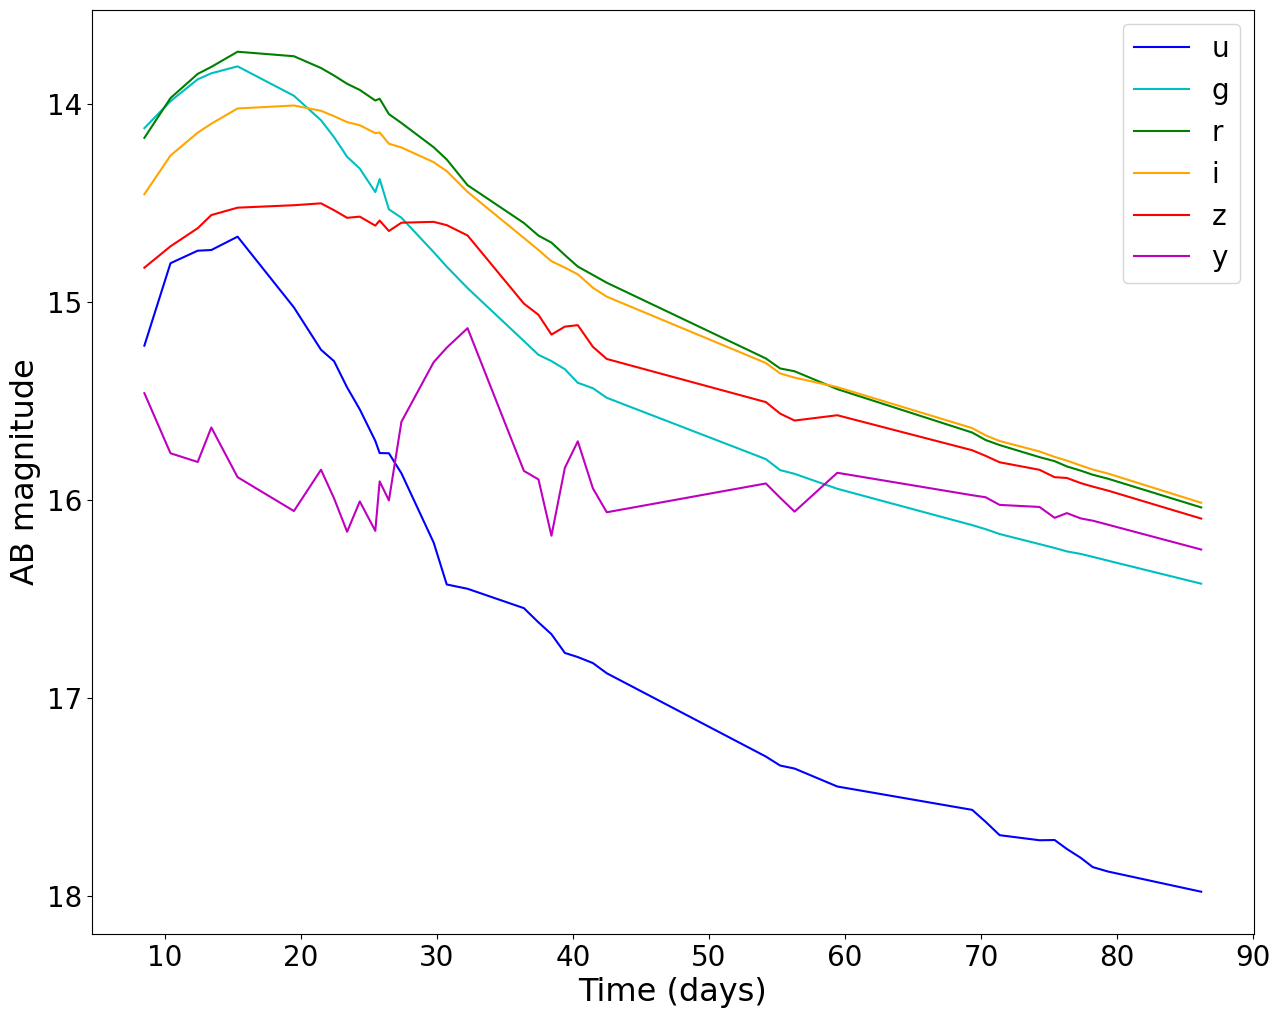

In [5]:
# plot the SN light curve
plt.rcParams.update({'font.size': 20})
plt.rcParams['figure.figsize'] = [15, 12]

nu_lsst = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 
             298760145396604.1] 
filters = ['u', 'g', 'r', 'i', 'z', 'y']
colors = ['b', 'c', 'g', 'orange', 'r', 'm']

z = 0.0085

for nu, c, f in zip(nu_lsst, colors, filters):
    
    magzlist = []
    t, fzlist = sn_light_curve(df_sn, nu, z)
    magzlist = -2.5 * np.log10(np.array(fzlist)*1.0e-26) - 48.6
    plt.plot(t, magzlist, color=c, label=f)
    
plt.xlabel('Time (days)', fontsize=23)
plt.ylabel('AB magnitude', fontsize=23)
plt.gca().invert_yaxis()
plt.legend()

## Plot SN and afterglow light curves on the same figure

In [6]:
# computing orphan GRB afterglow light curve
config = {'jetType':     grb.jet.PowerLaw,     # Jet Type
          'specType':    0,                  # Emission Spectrum
          'b':           4,       # Power Law index
          'thetaObs':    0.5,     # Viewing angle in radians
          'E0':          1.0e53,  # Isotropic-equivalent energy in erg
          'thetaWing':   0.15,    # Truncation angle in radians
          'thetaCore':   0.1,     # Half-opening angle in radians
          'n0':          1.0,     # Circumburst density in cm^{-3}
          'p':           2.2,     # Electron energy distribution index
          'epsilon_e':   0.1,     # epsilon_e
          'epsilon_B':   0.01,    # epsilon_B
          'xi_N':        1.0,     # Fraction of electrons accelerated
          'd_L':         1.17e26,  # Luminosity distance in cm
          'z':           0.0085}    # Redshift


#t = np.geomspace(1.0e3, 1.0e7, 300)
nu_lsst = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 
             298760145396604.1] 
colors = ['b', 'c', 'g', 'orange', 'r', 'm']

mag_grb = [[]]*6
t_grb = np.geomspace(1., 300, 100)

for i, nu in enumerate(nu_lsst):
    
    Fnu = grb.fluxDensity(t_grb * grb.day2sec, nu, **config)*1.0e-3
    mag_grb[i] = -2.5 * np.log10(Fnu*1.0e-23) - 48.6 

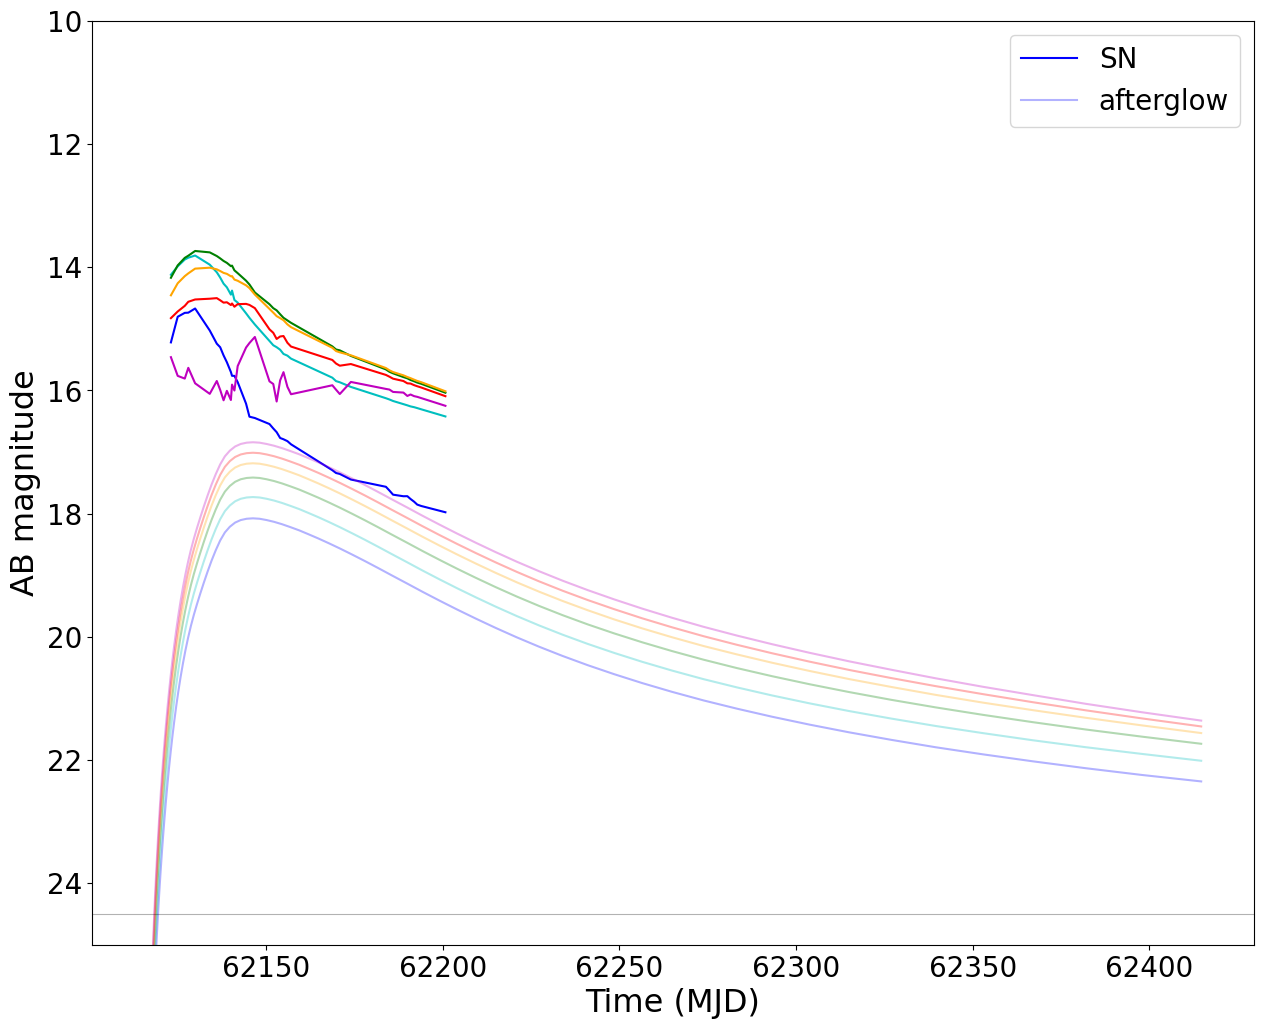

In [7]:
plt.rcParams.update({'font.size': 20})
plt.rcParams['figure.figsize'] = [15, 12]

T0 = Time(62114.62630306261, format='mjd', scale='utc')

for i, (nu, c) in enumerate(zip(nu_lsst, colors)):
    
    magzlist = []
    t, fzlist = sn_light_curve(df_sn, nu, z)
    magzlist = -2.5 * np.log10(np.array(fzlist)*1.0e-26) - 48.6
    
    if i == 0:
        plt.plot(t+Time(T0).mjd, magzlist, color=c, label='SN')
        plt.plot(t_grb+Time(T0).mjd, mag_grb[i], color=c, alpha=0.3, label='afterglow')
        
    else:
        plt.plot(t+Time(T0).mjd, magzlist, color=c)
        plt.plot(t_grb+Time(T0).mjd, mag_grb[i], color=c, alpha=0.3)
        
    
plt.axhline(y=24.5, lw=0.8, color='k', alpha=0.3)
plt.gca().invert_yaxis()
plt.xlabel('Time (MJD)', fontsize=23)
plt.ylabel('AB magnitude', fontsize=23)
#plt.xscale('log')
plt.ylim(25, 10)
plt.legend()